In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
df = pd.read_csv("/content/train.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
211816,2013-01-01,7,12,26
832656,2013-01-01,7,46,27
213642,2013-01-01,8,12,54
215468,2013-01-01,9,12,35


In [14]:
series = df[(df['store']==1) & (df['item']==1)][['date','sales']]
series = series.set_index('date')

series.head()

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10


In [17]:
full_range = pd.date_range(start=series.index.min(),
                           end=series.index.max(),
                           freq='D')
series = series.reindex(full_range)
series.index.name = 'date'
series['sales'] = series['sales'].interpolate()

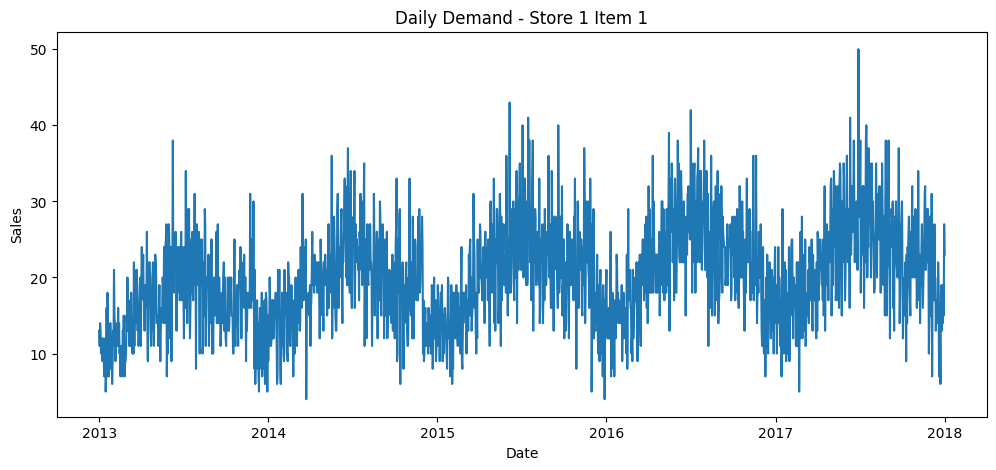

In [16]:
plt.figure(figsize=(12,5))
plt.plot(series.index, series['sales'])
plt.title("Daily Demand - Store 1 Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

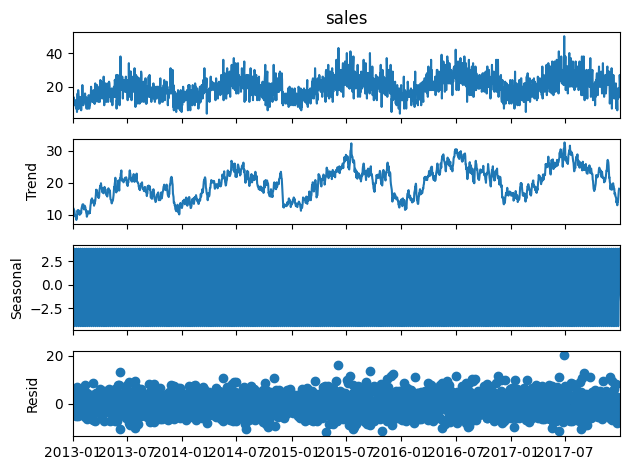

In [15]:
decomposition = seasonal_decompose(series['sales'],
                                   model='additive',
                                   period=7)

decomposition.plot()
plt.show()

In [ ]:
train = series.iloc[:-14]
test = series.iloc[-14:]

print("Train size:", len(train))
print("Test size:", len(test))

In [ ]:
naive_forecast = [train['sales'].iloc[-1]] * len(test)

plt.figure(figsize=(12,5))
plt.plot(train.index, train['sales'], label='Train')
plt.plot(test.index, test['sales'], label='Actual')
plt.plot(test.index, naive_forecast, label='Naive Forecast')
plt.legend()
plt.title("Naive Forecast")
plt.show()

In [ ]:
moving_avg = train['sales'].rolling(window=7).mean().iloc[-1]
ma_forecast = [moving_avg] * len(test)

plt.figure(figsize=(12,5))
plt.plot(train.index, train['sales'], label='Train')
plt.plot(test.index, test['sales'], label='Actual')
plt.plot(test.index, ma_forecast, label='Moving Average Forecast')
plt.legend()
plt.title("Moving Average Forecast")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"{name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

evaluate(test['sales'], naive_forecast, "Naive Forecast")
evaluate(test['sales'], ma_forecast, "Moving Average Forecast")

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train['sales'],
                order=(1,1,1),
                seasonal_order=(1,1,1,7),
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_model = model.fit(disp=False)

In [ ]:
sarima_forecast = sarima_model.forecast(steps=14)

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['sales'], label='Train')
plt.plot(test.index, test['sales'], label='Actual')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.legend()
plt.title("SARIMA Forecast (Improved Model)")
plt.show()

In [ ]:
evaluate(test['sales'], sarima_forecast, "SARIMA")

In [ ]:
final_model = SARIMAX(series['sales'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,7),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

final_fit = final_model.fit(disp=False)

In [ ]:
future_forecast = final_fit.forecast(steps=14)
future_forecast

In [ ]:
future_dates = pd.date_range(series.index[-1] + pd.Timedelta(days=1), periods=14)

future_df = pd.DataFrame({
    "date": future_dates,
    "predicted_sales": future_forecast.values
})

future_df

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(series.index[-60:], series['sales'][-60:], label="Historical")
plt.plot(future_dates, future_forecast, label="Next 14 Days Forecast", color='red')
plt.legend()
plt.title("Future Demand Forecast (Next 14 Days)")
plt.show()